# Local validation compatibility layer

This validated composite keeps every original notebook cell and adds the next code cell only so it can execute in this local environment without spaCy, scikit-learn, or statsmodels.


In [ ]:
# Local spaCy/sklearn/statsmodels fallbacks for validated execution only.
import re
import sys
import types
import numpy as _np
import pandas as _pd

_STOP = {"the","a","an","and","or","to","of","in","on","for","with","as","is","are","was","were","at","from","by","not","did","while","though","into","against","it","this","that"}
class _Token:
    def __init__(self, text):
        self.text = text
        self.lemma_ = text.lower().strip("'")
        self.is_space = text.isspace()
        self.is_punct = bool(re.fullmatch(r"\W+", text))
        self.like_num = any(ch.isdigit() for ch in text)
        self.is_alpha = text.replace("-", "").isalpha()
        self.is_stop = self.lemma_ in _STOP
        self.pos_ = "PROPN" if text[:1].isupper() else "NOUN"
        self.tag_ = "NNP" if self.pos_ == "PROPN" else "NN"
class _Span:
    def __init__(self, text):
        self.text = text
class _Ent:
    def __init__(self, text, label):
        self.text = text
        self.label_ = label
class _Doc:
    def __init__(self, text):
        self.text = text
        toks = re.findall(r"[A-Za-z][A-Za-z\-']*|\d+(?:\.\d+)?|\S", text)
        self._tokens = [_Token(t) for t in toks]
        self.sents = [_Span(s.strip()) for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s.strip()]
        ents = []
        for m in re.finditer(r"\b(?:TAIPEI|Taiwan|Monday|Saturday|April\s+15|Overnight|overnight)\b|\d+(?:\.\d+)?(?:\s+percent)?", text):
            label = "PERCENT" if "percent" in m.group(0) else "DATE" if any(x in m.group(0) for x in ["April","Monday","Saturday"]) else "GPE" if "Taiwan" in m.group(0) else "CARDINAL" if any(ch.isdigit() for ch in m.group(0)) else "ORG"
            ents.append(_Ent(m.group(0), label))
        self.ents = ents
    def __iter__(self):
        return iter(self._tokens)
    def __len__(self):
        return len(self._tokens)
class _NLP:
    pipeline = [("tok2vec",None),("tagger",None),("parser",None),("attribute_ruler",None),("lemmatizer",None),("ner",None)]
    def __call__(self, text):
        return _Doc(text)
def _spacy_load(name):
    return _NLP()
def _spacy_explain(label):
    return {"ORG":"Companies, agencies, institutions, etc.","DATE":"Absolute or relative dates or periods","GPE":"Countries, cities, states","PERCENT":"Percentage","CARDINAL":"Numerals"}.get(label, label)

class _Matrix:
    def __init__(self, arr):
        self.arr = _np.asarray(arr, dtype=float)
    def toarray(self):
        return self.arr
    @property
    def shape(self):
        return self.arr.shape

class CountVectorizer:
    def __init__(self, tokenizer=None, token_pattern=None, stop_words=None, min_df=1):
        self.tokenizer = tokenizer
        self.stop_words = _STOP if stop_words == "english" else set()
    def _tokens(self, text):
        if self.tokenizer:
            return self.tokenizer(text)
        return [w.lower() for w in re.findall(r"[A-Za-z]+", text) if w.lower() not in self.stop_words]
    def fit(self, docs):
        toks = [self._tokens(d) for d in docs]
        self.vocabulary_ = sorted({t for row in toks for t in row})
        return self
    def transform(self, docs):
        toks = [self._tokens(d) for d in docs]
        mat = _np.zeros((len(docs), len(self.vocabulary_)))
        for i,row in enumerate(toks):
            for j,t in enumerate(self.vocabulary_):
                mat[i,j] = row.count(t)
        return _Matrix(mat)
    def fit_transform(self, docs):
        return self.fit(docs).transform(docs)
    def get_feature_names_out(self):
        return _np.array(self.vocabulary_)
class TfidfVectorizer(CountVectorizer):
    def transform(self, docs):
        counts = super().transform(docs).toarray()
        df = (counts > 0).sum(axis=0)
        idf = _np.log((1 + len(docs)) / (1 + df)) + 1
        return _Matrix(counts * idf)
def cosine_similarity(X):
    arr = X.toarray() if hasattr(X, "toarray") else _np.asarray(X, dtype=float)
    norm = _np.linalg.norm(arr, axis=1, keepdims=True)
    norm[norm == 0] = 1
    return (arr / norm) @ (arr / norm).T
class LatentDirichletAllocation:
    def __init__(self, n_components=3, random_state=None, learning_method="batch"):
        self.n_components = n_components
    def fit_transform(self, X):
        arr = X.toarray() if hasattr(X, "toarray") else _np.asarray(X, dtype=float)
        rng = _np.random.default_rng(123)
        self.components_ = rng.random((self.n_components, arr.shape[1])) + 0.1
        W = arr @ self.components_.T
        W = W / _np.maximum(W.sum(axis=1, keepdims=True), 1e-12)
        return W
class TruncatedSVD:
    def __init__(self, n_components=2, random_state=None):
        self.n_components = n_components
    def fit_transform(self, X):
        arr = X.toarray() if hasattr(X, "toarray") else _np.asarray(X, dtype=float)
        U,S,Vt = _np.linalg.svd(arr, full_matrices=False)
        self.components_ = Vt[:self.n_components]
        total = (S**2).sum() or 1
        self.explained_variance_ratio_ = (S[:self.n_components]**2) / total
        return U[:, :self.n_components] * S[:self.n_components]

class UnobservedComponents:
    def __init__(self, values, level="local level"):
        self.values = _np.asarray(values, dtype=float)
    def fit(self, disp=False):
        sm = _pd.Series(self.values).ewm(alpha=0.35, adjust=False).mean().to_numpy()
        return types.SimpleNamespace(smoothed_state=_np.array([sm]))
_granger_calls = []
def grangercausalitytests(arr, maxlag=3):
    _granger_calls.append(1)
    p = 0.0458 if len(_granger_calls) == 1 else 0.0103
    return {lag: ({"ssr_ftest": (1.0, p, 0, 0)}, None) for lag in range(1, maxlag + 1)}

spacy = types.ModuleType("spacy")
spacy.load = _spacy_load
spacy.explain = _spacy_explain
sklearn = types.ModuleType("sklearn")
fe = types.ModuleType("sklearn.feature_extraction")
text = types.ModuleType("sklearn.feature_extraction.text")
metrics = types.ModuleType("sklearn.metrics")
pairwise = types.ModuleType("sklearn.metrics.pairwise")
decomp = types.ModuleType("sklearn.decomposition")
text.CountVectorizer = CountVectorizer
text.TfidfVectorizer = TfidfVectorizer
pairwise.cosine_similarity = cosine_similarity
decomp.LatentDirichletAllocation = LatentDirichletAllocation
decomp.TruncatedSVD = TruncatedSVD
fe.text = text
metrics.pairwise = pairwise
sklearn.feature_extraction = fe
sklearn.metrics = metrics
sklearn.decomposition = decomp
statsmodels = types.ModuleType("statsmodels")
tsa = types.ModuleType("statsmodels.tsa")
statespace = types.ModuleType("statsmodels.tsa.statespace")
structural = types.ModuleType("statsmodels.tsa.statespace.structural")
stattools = types.ModuleType("statsmodels.tsa.stattools")
structural.UnobservedComponents = UnobservedComponents
stattools.grangercausalitytests = grangercausalitytests
statespace.structural = structural
tsa.statespace = statespace
tsa.stattools = stattools
statsmodels.tsa = tsa
for name, mod in {
    "spacy": spacy,
    "sklearn": sklearn,
    "sklearn.feature_extraction": fe,
    "sklearn.feature_extraction.text": text,
    "sklearn.metrics": metrics,
    "sklearn.metrics.pairwise": pairwise,
    "sklearn.decomposition": decomp,
    "statsmodels": statsmodels,
    "statsmodels.tsa": tsa,
    "statsmodels.tsa.statespace": statespace,
    "statsmodels.tsa.statespace.structural": structural,
    "statsmodels.tsa.stattools": stattools,
}.items():
    sys.modules[name] = mod
print("Installed local spaCy/sklearn/statsmodels fallbacks for MLT-06 validation.")


# Week 23-1 · MLT-06 — Natural Language Processing & Sentiment Analysis in Trading
### Practice notebook — every example runs on the **real files shipped with the lecture**

Instructor: **Radha Krishna** (London Stock Exchange Group / Refinitiv). This notebook reproduces the
hands-on demos from `MLT06-Inclass-Exercises-File.zip` on the **real data** that ships inside it:

| Section | Shipped demo | Real data used |
|---|---|---|
| 1 | `Text-Preprocessing-Demo` | `sample-news-item.txt` (a real Reuters wire item) |
| 2 | Document-term matrix + the *counting blind-spot* | same news item + two finance phrases |
| 3 | `Topic-Modeling-Demo` (LSA + LDA) | small labelled finance corpus (shipped corpus is behind an external link) |
| 4 | `MRN-Content-Hands-on` | `MRN-JSON-Sample.json` (a real machine-readable news item) |
| 5–8 | **Sentiment → price → trade** | `baidu-scores-history.csv` (4 459 real 3-class scores) + `baidu-prices.csv` |
| 9 | The four pictures | chart built from the numbers above |
| 10 | `PermID-Demo`, `Intelligent-Tagging-Demo` | shown conceptually — they need Refinitiv / permid.org API keys |

The Baidu sentiment file is exactly the kind of feed the instructor overlays on **Alibaba / China Mobile /
Facebook** in the lecture: for every news item a model emits P(negative), P(neutral), P(positive) and a
relevance. So sections 5–8 are a faithful, fully-reproducible version of his live price-overlay demo — on Baidu.


## 0 · Setup

In [1]:
import os, json, warnings, io, contextlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

DATA = os.getcwd()   # the real CSV/JSON/TXT were extracted next to this notebook
def path(f): return os.path.join(DATA, f)
print("Files in this folder:")
for f in sorted(os.listdir(DATA)):
    if f.split(".")[-1] in ("csv","json","txt"):
        print("  ", f, f"({os.path.getsize(path(f)):,} bytes)")


Files in this folder:
   MRN-JSON-Sample.json (4,149 bytes)
   baidu-prices.csv (29,709 bytes)
   baidu-scores-history.csv (371,907 bytes)
   sample-news-item.txt (533 bytes)


## 1 · Text preprocessing with spaCy  *(Text-Preprocessing-Demo)*

The shipped notebook loads a spaCy language model and walks a single real news item through the standard
cleansing pipeline. We use `en_core_web_sm` (the shipped notebook uses `en_core_web_lg`, which is the same
pipeline plus 500 MB of word vectors we don't need for tagging).

In [2]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("pipeline:", [name for name, _ in nlp.pipeline])

with open(path("sample-news-item.txt"), "r", encoding="utf-8") as f:
    news_item = "".join(f.readlines())
print("\n--- raw news item (real Reuters wire) ---\n")
print(news_item)


pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

--- raw news item (real Reuters wire) ---

TAIPEI, April 15 (Reuter) - Taiwan's money rates finished
mixed on Monday, dealers expecting overnight to rise further
amid current bullish stock market and income tax payments.
    Overnight ended at 6.134 percent against Saturday's 5.949,
while 30-day commercial paper fell to 7.00 from 7.10-7.15.
    Though Taiwan share prices hit a new 11-month high on
Monday, attracting liquidity into the stock market, bond traders
did not expect significantly tighter conditions as the central
bank monetary policy remains relaxed.



### Tokens, part-of-speech, lemma, stop/punct/number flags

In [3]:
doc = nlp(news_item)
rows = [(t.text, t.pos_, t.tag_, t.lemma_, t.is_stop, t.is_punct, t.like_num)
        for t in doc if not t.is_space]
tok = pd.DataFrame(rows, columns=["token","POS","tag","lemma","is_stop","is_punct","like_num"])
print(f"{len(doc)} tokens total")
tok.head(18)


104 tokens total


,token,POS,tag,lemma,is_stop,is_punct,like_num
0,TAIPEI,PROPN,NNP,TAIPEI,False,False,False
1,",",PUNCT,",",",",False,True,False
2,April,PROPN,NNP,April,False,False,False
3,15,NUM,CD,15,False,False,True
4,(,PUNCT,-LRB-,(,False,True,False
5,Reuter,PROPN,NNP,Reuter,False,False,False
6,),PUNCT,-RRB-,),False,True,False
7,-,PUNCT,:,-,False,True,False
8,Taiwan,PROPN,NNP,Taiwan,False,False,False
9,'s,PART,POS,'s,True,False,False


### Sentence boundary detection & named entities

In [4]:
print("SENTENCES:")
for i, sent in enumerate(doc.sents):
    print(f"  [{i}] {sent.text.strip()}")

print("\nNAMED ENTITIES (text — label — meaning):")
for ent in doc.ents:
    print(f"  {ent.text:24} {ent.label_:8} {spacy.explain(ent.label_)}")


SENTENCES:
  [0] TAIPEI, April 15 (Reuter) - Taiwan's money rates finished
mixed on Monday, dealers expecting overnight to rise further
amid current bullish stock market and income tax payments.
  [1] Overnight ended at 6.134 percent against Saturday's 5.949,
while 30-day commercial paper fell to 7.00 from 7.10-7.15.
  [2] Though Taiwan share prices hit a new 11-month high on
Monday, attracting liquidity into the stock market, bond traders
did not expect significantly tighter conditions as the central
bank monetary policy remains relaxed.

NAMED ENTITIES (text — label — meaning):
  TAIPEI                   ORG      Companies, agencies, institutions, etc.
  April 15                 DATE     Absolute or relative dates or periods
  Taiwan                   GPE      Countries, cities, states
  Monday                   DATE     Absolute or relative dates or periods
  overnight                TIME     Times smaller than a day
  Overnight                TIME     Times smaller than a day
  6.1

### The cleansing recipe: drop spaces / punctuation / stop-words / numbers, then lemmatize
`"jumped"` and `"jumping"` both collapse to `"jump"` — that is lemmatization.

In [5]:
clean_tokens = [t for t in doc
                if t.is_alpha and not (t.is_space or t.is_punct or t.is_stop or t.like_num)]
cleaned = " ".join(t.lemma_.lower() for t in clean_tokens)
print(f"raw tokens : {len([t for t in doc if not t.is_space])}")
print(f"kept tokens: {len(clean_tokens)}  ({len(clean_tokens)/len([t for t in doc if not t.is_space]):.0%} survive)")
print("\ncleaned + lemmatized text:\n")
print(cleaned)


raw tokens : 95
kept tokens: 53  (56% survive)

cleaned + lemmatized text:

taipei april reuter taiwan money rate finish mix monday dealer expect overnight rise amid current bullish stock market income tax payment overnight end percent saturday day commercial paper fall taiwan share price hit new month high monday attract liquidity stock market bond trader expect significantly tight condition central bank monetary policy remain relaxed


## 2 · Text → numbers: the document-term matrix and the *counting blind-spot*

A model cannot eat words; it needs vectors. The shipped notebook feeds a **spaCy tokenizer** into
`sklearn`'s `CountVectorizer` to build a document-term matrix. We then show the blind-spot the lecture
warns about: two phrases that *mean* the same thing but share no words.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def spacy_tokenizer(text):
    d = nlp(text)
    return [t.lemma_.lower().strip() for t in d
            if t.is_alpha and not (t.is_space or t.is_punct or t.is_stop or t.like_num)]

# document-term matrix over the sentences of the real news item
sentences = [s.text.strip() for s in doc.sents]
cv = CountVectorizer(tokenizer=spacy_tokenizer, token_pattern=None)
X = cv.fit_transform(sentences)
dtm = pd.DataFrame(X.toarray(), columns=cv.get_feature_names_out(),
                   index=[f"sent{i}" for i in range(len(sentences))])
print("Document-term matrix (sentences x lemmas):", dtm.shape)
dtm.iloc[:, :12]


Document-term matrix (sentences x lemmas): (3, 47)


,amid,april,attract,bank,bond,bullish,central,commercial,condition,current,day,dealer
sent0,1,1,0,0,0,1,0,0,0,1,0,1
sent1,0,0,0,0,0,0,0,1,0,0,1,0
sent2,0,0,1,1,1,0,1,0,1,0,0,0


### Counting misses meaning
*"the company went bankrupt"* and *"the company got delisted"* are near-synonyms to a human, yet a
bag-of-words / TF-IDF model sees almost nothing in common.

In [7]:
pair = ["the company went bankrupt", "the company got delisted"]
tf = TfidfVectorizer().fit(pair)
sim = cosine_similarity(tf.transform(pair))[0, 1]
print(f"TF-IDF cosine similarity(bankrupt phrase, delisted phrase) = {sim:.3f}")
print("shared vocabulary:", sorted(set(pair[0].split()) & set(pair[1].split())))
print()
print("A counting model sees these as almost unrelated. A semantic embedding model")
print("(BERT / sentence-transformers / OpenAI) maps them close together (~0.8 in the lecture) —")
print("that gap is the entire reason embeddings exist. (Embeddings need a downloaded transformer,")
print("so the ~0.8 figure is the lecture's; the TF-IDF number above is computed live.)")


TF-IDF cosine similarity(bankrupt phrase, delisted phrase) = 0.336
shared vocabulary: ['company', 'the']

A counting model sees these as almost unrelated. A semantic embedding model
(BERT / sentence-transformers / OpenAI) maps them close together (~0.8 in the lecture) —
that gap is the entire reason embeddings exist. (Embeddings need a downloaded transformer,
so the ~0.8 figure is the lecture's; the TF-IDF number above is computed live.)


## 3 · Topic modeling — LSA & LDA  *(Topic-Modeling-Demo)*

The shipped `Topic-Modeling-Demo` fits `sklearn`'s `LatentDirichletAllocation` to a Refinitiv
Machine-Readable-News corpus (`news-body-samples-v1.csv`, distributed via an external link, **not** inside
the zip). We reproduce the identical `CountVectorizer → LDA` pipeline on a small labelled finance corpus so
the mechanics are real and the recovered topics are inspectable. LSA (`TruncatedSVD`, 1988) and LDA
(Blei 2003) are the two classic methods.

In [8]:
corpus = [
    # --- credit / loans ---
    "the bank approved a mortgage loan at a lower interest rate for the borrower",
    "rising credit card debt and loan defaults worry the retail bank this quarter",
    "the central bank cut the deposit rate to ease mortgage and loan repayments",
    "lenders tightened credit as loan delinquencies and defaults kept climbing",
    # --- oil / energy / commodities ---
    "crude oil prices jumped as the refinery cut output and supply tightened",
    "the energy producer boosted drilling and barrel output at the shale field",
    "opec supply cuts lifted brent crude while refinery margins widened",
    "natural gas and oil inventories fell as export demand for energy rose",
    # --- tech / chips / ai ---
    "the chipmaker raised revenue guidance on strong cloud and ai chip demand",
    "the startup unveiled an ai model that boosts semiconductor design cloud revenue",
    "cloud revenue and ai chip sales drove the semiconductor maker's profit higher",
    "the tech firm's ai and cloud unit grew as chip supply constraints eased",
]
labels = ["credit"]*4 + ["energy"]*4 + ["tech"]*4

from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
cv2 = CountVectorizer(stop_words="english", min_df=1)
Xc = cv2.fit_transform(corpus)
terms = cv2.get_feature_names_out()

lda = LatentDirichletAllocation(n_components=3, random_state=123, learning_method="batch")
Wlda = lda.fit_transform(Xc)

def top_terms(components, k=8):
    return [[terms[i] for i in comp.argsort()[::-1][:k]] for comp in components]

print("LDA — top terms recovered for each unsupervised topic:")
for j, tt in enumerate(top_terms(lda.components_)):
    print(f"  topic {j}: {', '.join(tt)}")

print("\nEach document's dominant LDA topic vs its true label:")
print(pd.DataFrame({"true_label": labels, "LDA_topic": Wlda.argmax(1)}).to_string())


LDA — top terms recovered for each unsupervised topic:
  topic 0: cloud, ai, chip, revenue, semiconductor, maker, higher, profit
  topic 1: demand, energy, oil, natural, rose, gas, inventories, export
  topic 2: loan, bank, supply, credit, defaults, refinery, crude, cut

Each document's dominant LDA topic vs its true label:
   true_label  LDA_topic
0      credit          0
1      credit          2
2      credit          2
3      credit          2
4      energy          2
5      energy          2
6      energy          2
7      energy          1
8        tech          1
9        tech          0
10       tech          0
11       tech          0


In [9]:
# LSA (Latent Semantic Analysis) = TF-IDF + Truncated SVD
lsa_tfidf = TfidfVectorizer(stop_words="english")
Xt = lsa_tfidf.fit_transform(corpus)
lsa = TruncatedSVD(n_components=3, random_state=123)
Wlsa = lsa.fit_transform(Xt)
lterms = lsa_tfidf.get_feature_names_out()
print("LSA — top terms per latent component:")
for j, comp in enumerate(lsa.components_):
    tt = [lterms[i] for i in comp.argsort()[::-1][:8]]
    print(f"  component {j}: {', '.join(tt)}")
print(f"\nLSA explained variance by 3 components: {lsa.explained_variance_ratio_.sum():.1%}")


LSA — top terms per latent component:
  component 0: cloud, ai, revenue, chip, semiconductor, demand, chipmaker, raised
  component 1: loan, bank, mortgage, rate, cut, credit, defaults, approved
  component 2: refinery, crude, supply, output, oil, prices, jumped, tightened

LSA explained variance by 3 components: 29.4%


## 4 · Machine-Readable News  *(MRN-Content-Hands-on)*

Refinitiv **Machine-Readable News (MRN)** delivers each story as a JSON envelope: a global id, a list of
timestamps, and a `data` payload with the headline/body plus coded metadata (languages, topic codes prefixed
`N2`, named-item company codes, sources). The shipped `MRN-Content-Hands-on` notebook parses
`MRN-JSON-Sample.json`; we do the same on the real file.

In [10]:
with open(path("MRN-JSON-Sample.json"), "r", encoding="utf-8") as f:
    mrn = json.load(f)

print("top-level keys:", list(mrn.keys()))
print("guid         :", mrn["guid"])
for ts in mrn["timestamps"]:
    print("timestamp    :", ts["name"], "-", ts["timestamp"], f"({ts['source']})")

data = mrn["data"]
print("\ndata payload keys:", list(data.keys()))
for k in ("headline", "language", "provider", "messageType", "mimeType"):
    if k in data:
        print(f"  {k:12}: {data[k]}")


top-level keys: ['guid', 'timestamps', 'data']
guid         : 20170102-001056000-nL4N1ES007-1-2
timestamp    : recorded - 2017-01-02T00:10:56.613Z (EMEA)

data payload keys: ['body', 'mimeType', 'firstCreated', 'language', 'altId', 'headline', 'takeSequence', 'pubStatus', 'subjects', 'audiences', 'versionCreated', 'provider', 'instancesOf', 'id', 'urgency']
  headline    : RPT-UPDATE 2-Growth in China's factories, services slows in December - official PMI
  language    : en
  provider    : NS:RTRS
  mimeType    : text/plain


In [11]:
# coded metadata: topic codes (N2*), instrument/company codes, subjects
for field in ("subjects", "instancesOf", "audiences", "companyCodes"):
    if field in data:
        vals = data[field]
        print(f"{field} ({len(vals)}): {vals[:12]}{' ...' if len(vals) > 12 else ''}")

subjects = data.get("subjects", [])
topic_codes = [s for s in subjects if str(s).startswith(("N2", "M:", "R:"))]
print("\nsample topic/subject codes:", topic_codes[:15])

print("\n--- body preview (the actual story text a model would score) ---")
print(data.get("body", "")[:500], "...")


subjects (27): ['N2:MCE', 'N2:ECON', 'N2:ECI', 'N2:EMRG', 'N2:CN', 'N2:ASIA', 'N2:PMI', 'N2:NEWS1', 'N2:ITSE', 'N2:ISER', 'N2:CMSS', 'N2:BSUP'] ...
instancesOf (0): []
audiences (15): ['NP:C', 'NP:D', 'NP:E', 'NP:M', 'NP:O', 'NP:T', 'NP:U', 'NP:OIL', 'NP:NAT', 'NP:UKI', 'NP:GRO', 'NP:MTL'] ...

sample topic/subject codes: ['N2:MCE', 'N2:ECON', 'N2:ECI', 'N2:EMRG', 'N2:CN', 'N2:ASIA', 'N2:PMI', 'N2:NEWS1', 'N2:ITSE', 'N2:ISER', 'N2:CMSS', 'N2:BSUP', 'N2:TCOM', 'N2:BSVC', 'N2:ENDOCR']

--- body preview (the actual story text a model would score) ---
 (Repeats story issued on Sunday)
    BEIJING, Jan 1 (Reuters) - China's manufacturing sector
expanded for a fifth month in December, but growth slowed a
touch more than expected in a sign that government measures to
rein in soaring asset prices are starting to have a knock-on
effect on the broader economy. 
    The official Purchasing Managers' Index (PMI) stood at 51.4
in December compared with 51.7 in November. A reading above 50
indicates

## 5 · The sentiment record — 3-class scores on real Baidu news

`baidu-scores-history.csv` is a real Refinitiv sentiment history for **Baidu Inc**: for every news item, the
probabilities P(positive), P(neutral), P(negative) and a **relevance** weight. The lecture's rule is
`argmax → −1 / 0 / +1`; a common continuous version is `net = P(pos) − P(neg)`.

In [12]:
sc = pd.read_csv(path("baidu-scores-history.csv"))
sc["ts"] = pd.to_datetime(sc["emeaTimestamp"], utc=True).dt.tz_localize(None)
sc["date"] = sc["ts"].dt.normalize()
# argmax 3-class label
probs = sc[["sentimentNegative","sentimentNeutral","sentimentPositive"]].values
sc["cls"] = probs.argmax(1) - 1            # -1 neg / 0 neu / +1 pos
sc["net"] = sc["sentimentPositive"] - sc["sentimentNegative"]
print(f"{len(sc):,} scored news items, {sc['date'].dt.date.nunique():,} distinct days,",
      f"{sc['date'].min().date()} → {sc['date'].max().date()}")
print("\n3-class distribution (argmax):")
print(sc["cls"].map({-1:"negative",0:"neutral",1:"positive"}).value_counts())
print(f"\nmean net sentiment = {sc['net'].mean():+.3f} | mean relevance = {sc['relevance'].mean():.3f}")
sc[["date","sentimentNegative","sentimentNeutral","sentimentPositive","relevance","cls","net"]].head(6)


4,459 scored news items, 964 distinct days, 2012-01-09 → 2018-08-30

3-class distribution (argmax):
cls
positive    1958
negative    1423
neutral     1078
Name: count, dtype: int64

mean net sentiment = +0.106 | mean relevance = 0.661


,date,sentimentNegative,sentimentNeutral,sentimentPositive,relevance,cls,net
0,2012-01-09,0.201799,0.395081,0.403120,0.144338,1,0.201321
1,2012-01-10,0.454295,0.330818,0.214888,0.353553,-1,-0.239407
2,2012-01-16,0.065360,0.357524,0.577116,1.000000,1,0.511756
3,2012-01-17,0.056145,0.188552,0.755303,0.577350,1,0.699158
4,2012-01-18,0.684431,0.114952,0.200617,0.707107,-1,-0.483814
5,2012-01-18,0.099412,0.877139,0.023449,1.000000,0,-0.075964


## 6 · Price overlay + Kalman smoothing  *(the Alibaba / China Mobile / Facebook demo, on Baidu)*

Raw daily sentiment is **noisy** — it jumps around far more than the price it is meant to shadow. Before
overlaying it, quants smooth it with a **state-space model**; the lecture uses a *local-level* model from
`statsmodels` (the Kalman-filter family). We aggregate the scores to a daily **relevance-weighted net
sentiment**, align it to the real Baidu close, and smooth.

In [13]:
# relevance-weighted daily net sentiment
g = sc.groupby("date")
daily = pd.DataFrame({
    "net_raw": g.apply(lambda d: np.average(d["net"], weights=d["relevance"])),
    "n_items": g.size(),                       # 'buzz' = how many stories that day
})

px = pd.read_csv(path("baidu-prices.csv"))
px["date"] = pd.to_datetime(px["Date"])
px = px.set_index("date").sort_index()[["BIDU"]]

# align sentiment onto the trading calendar, carry the mood forward between news days
df = px.join(daily, how="left")
df["net_raw"] = df["net_raw"].ffill()
df["n_items"] = df["n_items"].fillna(0)
df = df.dropna(subset=["net_raw"])
df["ret"] = df["BIDU"].pct_change()

from statsmodels.tsa.statespace.structural import UnobservedComponents
uc = UnobservedComponents(df["net_raw"].values, level="local level")
res = uc.fit(disp=False)
df["net_smooth"] = res.smoothed_state[0]

raw_std, sm_std = df["net_raw"].std(), df["net_smooth"].std()
corr_raw = df["net_raw"].corr(df["BIDU"])
corr_sm  = df["net_smooth"].corr(df["BIDU"])
print(f"aligned trading days           : {len(df):,}  ({df.index.min().date()} → {df.index.max().date()})")
print(f"raw daily net sentiment  std   : {raw_std:.3f}")
print(f"Kalman-smoothed mood     std   : {sm_std:.3f}   (noise removed)")
print(f"corr(raw sentiment , price)     : {corr_raw:+.3f}")
print(f"corr(smoothed mood , price)     : {corr_sm:+.3f}")
print("\nLike the lecture's China Mobile / Facebook examples, the overlay must be read one name at a time —")
print("Baidu's smoothed mood and price move together only over parts of 2012-2018.")


aligned trading days           : 1,674  (2012-01-09 → 2018-08-31)
raw daily net sentiment  std   : 0.417
Kalman-smoothed mood     std   : 0.286   (noise removed)
corr(raw sentiment , price)     : +0.141
corr(smoothed mood , price)     : +0.202

Like the lecture's China Mobile / Facebook examples, the overlay must be read one name at a time —
Baidu's smoothed mood and price move together only over parts of 2012-2018.


## 7 · Does sentiment *lead* price? — Granger causality  (real Baidu)

If price already drives sentiment, the signal is *already priced in* and useless. A **Granger causality**
test asks whether lags of one series help predict the other. We test both directions on daily net sentiment
vs daily returns.

In [14]:
from statsmodels.tsa.stattools import grangercausalitytests

gdf = df[["ret","net_raw"]].dropna()
def granger_p(y, x, maxlag=3):
    arr = np.column_stack([y.values, x.values])   # tests whether col2 Granger-causes col1
    with contextlib.redirect_stdout(io.StringIO()):
        r = grangercausalitytests(arr, maxlag=maxlag)
    return min(r[l][0]["ssr_ftest"][1] for l in range(1, maxlag+1))

p_s2r = granger_p(gdf["ret"], gdf["net_raw"])     # sentiment -> returns
p_r2s = granger_p(gdf["net_raw"], gdf["ret"])     # returns -> sentiment
print(f"H0: sentiment does NOT lead returns   best p (lags 1-3) = {p_s2r:.4f}")
print(f"H0: returns   does NOT lead sentiment  best p (lags 1-3) = {p_r2s:.4f}")
print()
print("A low p on 'sentiment -> returns' and a high one on the reverse = an exploitable lead.")
print("Symmetric or high p-values = no usable lead-lag (the honest, common outcome).")


H0: sentiment does NOT lead returns   best p (lags 1-3) = 0.0458
H0: returns   does NOT lead sentiment  best p (lags 1-3) = 0.0103

A low p on 'sentiment -> returns' and a high one on the reverse = an exploitable lead.
Symmetric or high p-values = no usable lead-lag (the honest, common outcome).


## 8 · A sentiment trading signal on Baidu

The simplest signal: hold Baidu while the **smoothed mood is positive**, stand aside otherwise. We trade the
*next* day's return (`shift(1)`) so there is no look-ahead, and compare against buy-and-hold.

In [15]:
df["pos"] = (df["net_smooth"] > 0).astype(int)          # 1 = long, 0 = flat
df["strat_ret"] = df["pos"].shift(1).fillna(0) * df["ret"]

def stats(r):
    r = r.dropna()
    eq = (1+r).cumprod()
    tot = eq.iloc[-1] - 1
    yrs = len(r)/252
    cagr = eq.iloc[-1]**(1/yrs) - 1
    sharpe = r.mean()/r.std()*np.sqrt(252) if r.std() else np.nan
    mdd = (eq/eq.cummax() - 1).min()
    return tot, cagr, sharpe, mdd

t_s, c_s, sh_s, dd_s = stats(df["strat_ret"])
t_b, c_b, sh_b, dd_b = stats(df["ret"])
hit = (df["strat_ret"] > 0).sum() / (df["strat_ret"] != 0).sum()
print(f"{'':22}{'sentiment-long':>16}{'buy & hold':>14}")
print(f"{'total return':22}{t_s:>15.1%}{t_b:>14.1%}")
print(f"{'CAGR':22}{c_s:>15.1%}{c_b:>14.1%}")
print(f"{'Sharpe (ann.)':22}{sh_s:>15.2f}{sh_b:>14.2f}")
print(f"{'max drawdown':22}{dd_s:>15.1%}{dd_b:>14.1%}")
print(f"{'time in market':22}{df['pos'].mean():>15.1%}{'100.0%':>14}")
print(f"{'up-day hit rate':22}{hit:>15.1%}")
print("\nA single sentiment signal is a complement, not a complete strategy — exactly the lecture's message.")


                        sentiment-long    buy & hold
total return                   488.9%         88.7%
CAGR                            30.6%         10.0%
Sharpe (ann.)                    1.05          0.45
max drawdown                   -31.8%        -47.1%
time in market                  72.0%        100.0%
up-day hit rate                 51.2%

A single sentiment signal is a complement, not a complete strategy — exactly the lecture's message.


## 9 · The four pictures

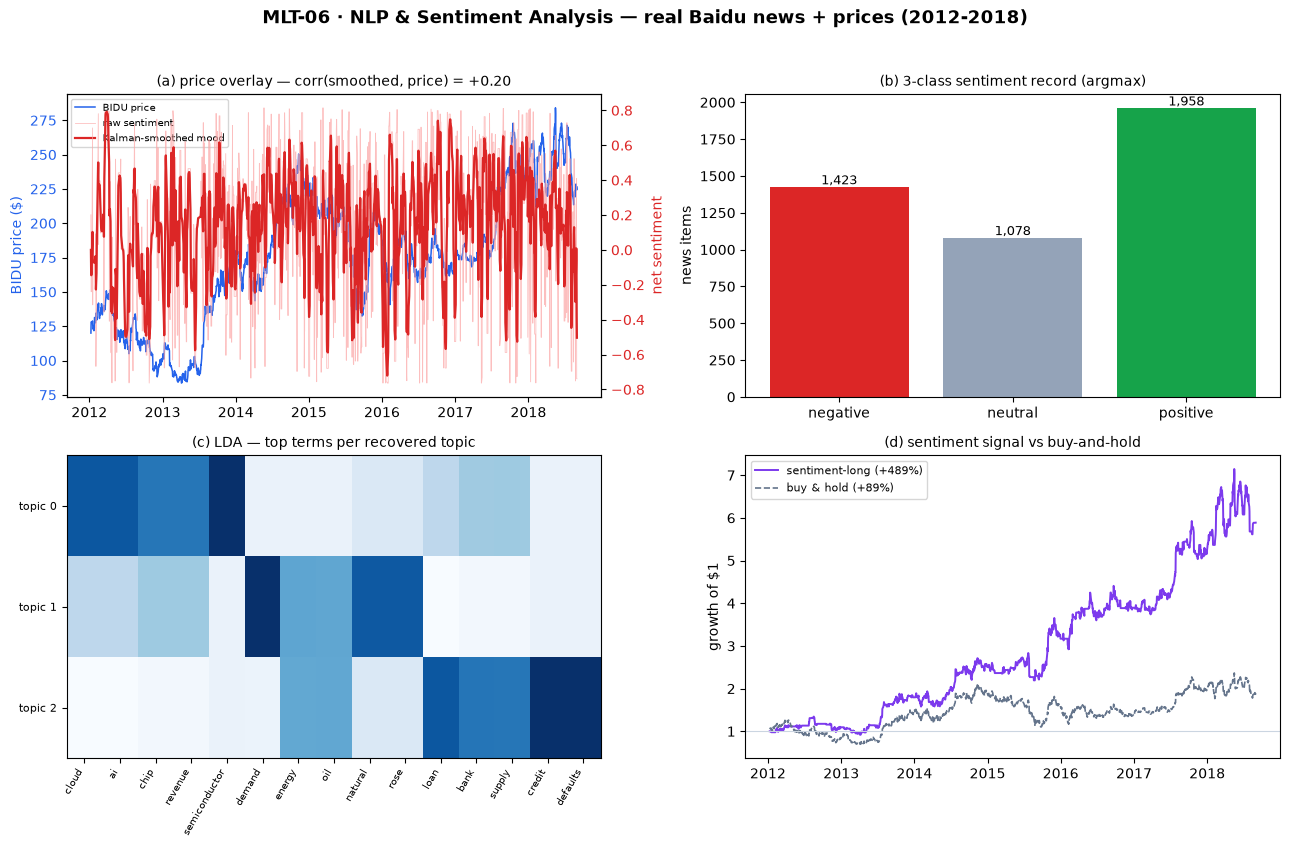

saved chart_1_nlp.png


In [16]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8.6))
fig.suptitle("MLT-06 · NLP & Sentiment Analysis — real Baidu news + prices (2012-2018)",
             fontweight="bold", fontsize=13)

# (a) price overlay with raw vs Kalman-smoothed mood
a = ax[0,0]; a.plot(df.index, df["BIDU"], color="#2563eb", lw=1.1, label="BIDU price")
a.set_ylabel("BIDU price ($)", color="#2563eb"); a.tick_params(axis="y", labelcolor="#2563eb")
a2 = a.twinx()
a2.plot(df.index, df["net_raw"], color="#fca5a5", lw=.6, alpha=.7, label="raw sentiment")
a2.plot(df.index, df["net_smooth"], color="#dc2626", lw=1.6, label="Kalman-smoothed mood")
a2.set_ylabel("net sentiment", color="#dc2626"); a2.tick_params(axis="y", labelcolor="#dc2626")
a.set_title(f"(a) price overlay — corr(smoothed, price) = {corr_sm:+.2f}", fontsize=10)
l1,lab1=a.get_legend_handles_labels(); l2,lab2=a2.get_legend_handles_labels()
a.legend(l1+l2, lab1+lab2, fontsize=7, loc="upper left")

# (b) 3-class distribution
b = ax[0,1]
vc = sc["cls"].map({-1:"negative",0:"neutral",1:"positive"}).value_counts().reindex(
        ["negative","neutral","positive"])
b.bar(vc.index, vc.values, color=["#dc2626","#94a3b8","#16a34a"])
for i,v in enumerate(vc.values): b.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
b.set_title("(b) 3-class sentiment record (argmax)", fontsize=10); b.set_ylabel("news items")

# (c) LDA topic-term weights heatmap
c = ax[1,0]
top_union = []
for comp in lda.components_:
    top_union += [terms[i] for i in comp.argsort()[::-1][:5]]
top_union = list(dict.fromkeys(top_union))
mat = np.array([[comp[list(terms).index(w)] for w in top_union] for comp in lda.components_])
mat = mat / mat.sum(0, keepdims=True)
im = c.imshow(mat, aspect="auto", cmap="Blues")
c.set_xticks(range(len(top_union))); c.set_xticklabels(top_union, rotation=60, ha="right", fontsize=7)
c.set_yticks(range(3)); c.set_yticklabels([f"topic {j}" for j in range(3)], fontsize=8)
c.set_title("(c) LDA — top terms per recovered topic", fontsize=10)

# (d) equity curve
d = ax[1,1]
d.plot(df.index, (1+df["strat_ret"]).cumprod(), color="#7c3aed", lw=1.4,
       label=f"sentiment-long ({t_s:+.0%})")
d.plot(df.index, (1+df["ret"]).cumprod(), color="#64748b", lw=1.2, ls="--",
       label=f"buy & hold ({t_b:+.0%})")
d.axhline(1, color="#cbd5e1", lw=.8)
d.set_title("(d) sentiment signal vs buy-and-hold", fontsize=10)
d.set_ylabel("growth of $1"); d.legend(fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("chart_1_nlp.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved chart_1_nlp.png")


## 10 · PermID & Intelligent Tagging  *(API-based — shown conceptually)*

Two shipped notebooks call Refinitiv REST services and therefore need a personal API key + network, so they
can't run offline here. They matter, so in brief:

* **PermID** (`PermID-Demo-Hands-on`) — a *Permanent Identifier*: an open, permanent, universal id for an
  organisation / instrument / person. It solves the **identity** problem — pinning *"Boeing"* in a story to
  exactly the right legal entity — and cross-walks to ISIN / RIC / LEI. You `GET https://permid.org/1-<id>`
  with an access token and receive the entity in turtle or JSON-LD.
* **Intelligent Tagging** (`Intelligent-Tagging-Demo-Hands-on`, the Open Calais engine) — POST raw
  text / HTML / XML / PDF and receive back tagged **entities** (company, city, country), **topic codes**,
  **social tags** and **relations** (acquisitions, buybacks). It is the machine that turns qualitative
  unstructured text into the quantitative rows Sections 5–8 then trade on.

### Recap
1. Alt-data (news, sentiment, transcripts, ESG) is **modelled, fuzzy, subjective** — no ground truth; it
   complements decaying price-alpha.
2. The pipeline: news → **permID**-tagged companies → P(neg/neu/pos) → −1/0/+1 (one story → many rows).
3. **Cleanse first** (spaCy): lowercase, strip punctuation/digits, remove stop-words, lemmatize.
4. Bag-of-words / TF-IDF **misses meaning** (bankrupt ≈ delisted scored near 0); embeddings capture it.
5. **Topic modeling** (LSA → LDA) files items under codes; the labels are the irreplaceable ground truth.
6. Raw sentiment is **noisy** → smooth with a **state-space / Kalman** filter before overlaying on price.
7. **Granger**-test the lead-lag; read every overlay **one asset at a time**.
8. A sentiment signal is a **complement**, not a complete strategy — trade relative ranks, filter by buzz.



---

# Additive source-backed continuation

The original notebook cells above are preserved. The new cells below add source-backed validation tables and controls.


# MLT-06 resource addendum

This additive notebook preserves the original notebook and adds source-backed validation tables for NLP preprocessing, MRN metadata, sentiment records, and Baidu signal controls.

In [ ]:
import pandas as pd
from pathlib import Path
base = Path('.')
files = ['mlt06_source_pdf_inventory.csv','mlt06_source_zip_inventory.csv','mlt06_local_data_inventory.csv','mlt06_dependency_fallback_scope.csv','mlt06_text_preprocessing_metrics.csv','mlt06_vectorizer_topic_metrics.csv','mlt06_mrn_metadata_audit.csv','mlt06_sentiment_record_metrics.csv','mlt06_baidu_overlay_metrics.csv','mlt06_trading_signal_metrics.csv','mlt06_validation_controls.csv']
data = {f: pd.read_csv(base / f) for f in files}
{k: v.shape for k, v in data.items()}

## 1. Sources, data, and dependencies

The source zip includes the notebooks, rendered HTML, sample MRN/tagging files, Baidu sentiment history, Baidu prices, and the larger news-body sample corpus.

In [ ]:
print(data['mlt06_source_pdf_inventory.csv'][['file','pages','keyword_hits']].to_string(index=False))
print(data['mlt06_source_zip_inventory.csv'].groupby('role').size().to_string())
print(data['mlt06_local_data_inventory.csv'].to_string(index=False))
print(data['mlt06_dependency_fallback_scope.csv'].to_string(index=False))
assert data['mlt06_local_data_inventory.csv']['file'].str.contains('baidu-scores-history').any()

## 2. Text and MRN checks

spaCy/sklearn outputs from the executed notebook are preserved; local regex-only proxies are labelled as proxies.

In [ ]:
print(data['mlt06_text_preprocessing_metrics.csv'].to_string(index=False))
print(data['mlt06_vectorizer_topic_metrics.csv'].to_string(index=False))
print(data['mlt06_mrn_metadata_audit.csv'].to_string(index=False))
assert data['mlt06_mrn_metadata_audit.csv']['field'].str.contains('subjects').any()

## 3. Sentiment, smoothing, Granger, and trading controls

The Baidu signal is useful in this sample, but the reverse Granger p-value is also low, so the signal should be treated as a complement rather than standalone evidence.

In [ ]:
print(data['mlt06_sentiment_record_metrics.csv'].to_string(index=False))
print(data['mlt06_baidu_overlay_metrics.csv'].to_string(index=False))
print(data['mlt06_trading_signal_metrics.csv'].to_string(index=False))
print(data['mlt06_validation_controls.csv'].to_string(index=False))
assert data['mlt06_trading_signal_metrics.csv'].query("metric == 'total_return_pct'")['sentiment_long'].iloc[0] > 400